In [1]:
import sys
sys.path.append('../')

from BPMQ import *
import numpy as np

import torch
torch.set_num_threads(2)

In [2]:
machineIO = construct_machineIO()
machineIO._test = True
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 1
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.2

E_MeVu = 130
Mass_number = 18
Charge_number = 8

# preprare BPMQ scan

In [3]:
# Example usage (assuming you have the helper functions defined as before):
filename = "lattice.txt"  # Replace with your lattice file
from_elem = "BDS_BTS:QV_D5501"
to_elem = "BDS_BTS:PM_D5567"
lattice_dicts = fmlat.combine_lattice_elements_quads_only(filename, from_element=from_elem, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])
#, line_name = "cell")
# qnames = ["BDS_BTS:PSQ_D5501", "BDS_BTS:PSQ_D5509", "BDS_BTS:PSQ_D5552", "BDS_BTS:PSQ_D5559"]
qnames = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
qnames = qnames[-4:]
qnames

['BDS_BTS:PSQ_D5501',
 'BDS_BTS:PSQ_D5509',
 'BDS_BTS:PSQ_D5552',
 'BDS_BTS:PSQ_D5559']

In [4]:
args = (E_MeVu, Mass_number, Charge_number)
kwargs = {
    "quads_to_scan": qnames,
    "quads_max_curr": [180, 180, 180, 180],
    "quads_min_curr": [ 10,  10,  10,  10],
    "BPM_names": ["BDS_BTS:BPM_D5513", "BDS_BTS:BPM_D5565"],
    "lattice_dicts" : lattice_dicts,
    "xnemit_target": None,
    "ynemit_target": None,
    "ISAAC_preset_keywords":["BDS"],
    "bootstrap":False,
    "machineIO": None,
    "plot_history":True, 
    "plot_ellipse":True,
    "fit_err":False
}

# Run for various virtual Qerrs

In [5]:
def measure_rms(bpmQscan):
    env_model = bpmQscan.quads_evaluator.env_model
    xcov, ycov = env_model.simulate_beam_covars(env_model.xcovs,env_model.ycovs,i_monitors=env_model.i_pms)
    xrms, yrms = xcov[0,0,0,0]**0.5*1e3, ycov[0,0,0,0]**0.5*1e3
    lB2 = []
    for quad in env_model.quads_to_scan:
        lB2.append(quad.properties['B2'])
    return lB2, xrms, yrms

after init, number of training data is 4
 ======== cs_reconstruct ========
Exiting early at iteration 101 due to large loss


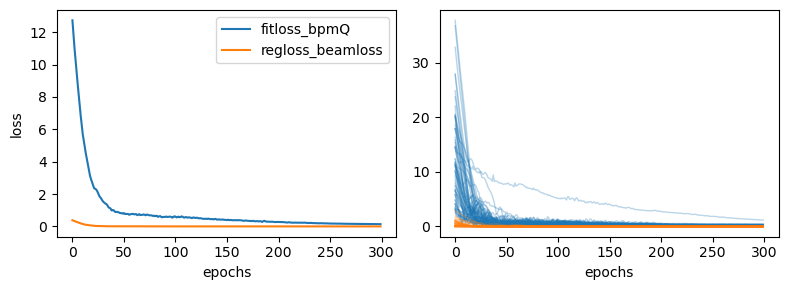

6.376824706999287


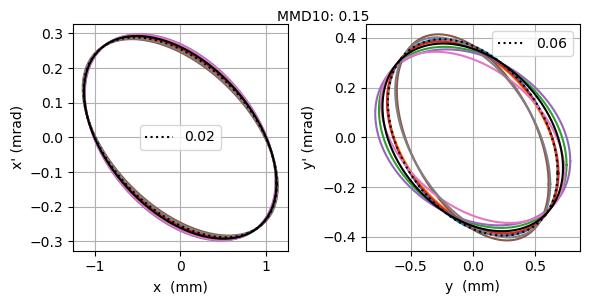

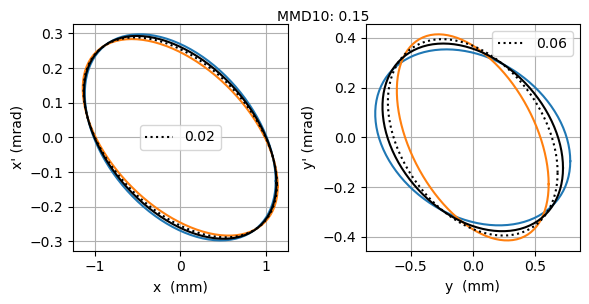

In [6]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs, 
                    virtual_beamQerr=0.0)
bpmQscan.initialize()
print(time.monotonic()-start_time)

In [7]:
loss_ftn, loss_ftn_wo_beamloss, x0 = bpmQscan.train_model(retrun_loss_ftn_4_debug=True)

 ======== cs_reconstruct ========


In [10]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU],
    schedule=torch.profiler.schedule(
        wait=1, warmup=1, active=3, repeat=1  # Helps prevent start/stop issues
    ),
    record_shapes=True,
    profile_memory=True,
    with_stack=True
) as prof:
    for _ in range(100):  # Ensure multiple profiling steps
        loss_ftn(x0)
        prof.step()  # Required when using a schedule

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=10))

import pandas as pd
from IPython.display import display

# Filter out entries with the key "ProfilerStep*"
key_avgs = [entry for entry in prof.key_averages() if entry.key != "ProfilerStep*"]

df = pd.DataFrame([{
    "Name": entry.key,
    "CPU total (us)": entry.cpu_time_total,  # Total CPU time in microseconds
#     "Avg CPU time (us)": entry.cpu_time_total / entry.count if entry.count else 0,
    "# of Calls": entry.count
} for entry in key_avgs])
total_cpu = df["CPU total (us)"].sum()
df["CPU %"] = (df["CPU total (us)"] / total_cpu * 100).round(2)
df.sort_values(by="CPU total (us)", ascending=False).reset_index(drop=True).head()

STAGE:2025-04-03 10:27:34 6385:6385 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2025-04-03 10:27:34 6385:6385 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-04-03 10:27:34 6385:6385 ActivityProfilerController.cpp:324] Completed Stage: Post Processing


-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
          ProfilerStep*        50.44%       6.749ms       100.00%      13.379ms       4.460ms           0 b    -728.14 Kb             3  
              aten::bmm         9.84%       1.317ms         9.84%       1.317ms       5.487us     240.00 Kb     224.00 Kb           240  
            aten::copy_         7.06%     944.000us         7.06%     944.000us       4.917us           0 b           0 b           192  
           aten::select         6.62%     886.000us         6.78%     907.000us       3.286us           0 b           0 b           276  
              aten::pow         5.

,Name,CPU total (us),# of Calls,CPU %
0,aten::bmm,1317,240,17.61
1,aten::copy_,944,192,12.62
2,aten::select,907,276,12.13
3,aten::pow,768,12,10.27
4,aten::slice,473,114,6.32


In [11]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU],
    schedule=torch.profiler.schedule(
        wait=1, warmup=1, active=3, repeat=1  # Helps prevent start/stop issues
    ),
    record_shapes=True,
    profile_memory=True,
    with_stack=True
) as prof:
    for _ in range(100):  # Ensure multiple profiling steps
        loss_ftn_wo_beamloss(x0)
        prof.step()  # Required when using a schedule

#print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=10))

import pandas as pd
from IPython.display import display

# Filter out entries with the key "ProfilerStep*"
key_avgs = [entry for entry in prof.key_averages() if entry.key != "ProfilerStep*"]

df = pd.DataFrame([{
    "Name": entry.key,
    "CPU total (us)": entry.cpu_time_total,  # Total CPU time in microseconds
#     "Avg CPU time (us)": entry.cpu_time_total / entry.count if entry.count else 0,
    "# of Calls": entry.count
} for entry in key_avgs])
total_cpu = df["CPU total (us)"].sum()
df["CPU %"] = (df["CPU total (us)"] / total_cpu * 100).round(2)
df.sort_values(by="CPU total (us)", ascending=False).reset_index(drop=True).head()

STAGE:2025-04-03 10:27:39 6385:6385 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2025-04-03 10:27:39 6385:6385 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2025-04-03 10:27:39 6385:6385 ActivityProfilerController.cpp:324] Completed Stage: Post Processing


,Name,CPU total (us),# of Calls,CPU %
0,aten::pow,535,12,12.50
1,aten::bmm,450,48,10.51
2,aten::slice,448,114,10.46
3,aten::select,444,156,10.37
4,aten::copy_,282,72,6.59
